In [1]:
import pyomo.environ as pyo
import mpisppy.utils.sputils as sputils
from mpisppy.opt.ef import ExtensiveForm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Configuração para que os gráficos apareçam inline no Jupyter
%matplotlib inline

[    0.00] Initializing mpi-sppy


In [2]:
from utils import carregar_pld_12m, gerar_perfis_realistas, carregar_geracao_data
from utils import load_and_process_scenario_data, plot_scenario_results

In [3]:
# --- Configuração do Horizonte de Tempo ---
TIME_HORIZON_DIAS = 15
INTERVALO_HORAS = 0.25  # 15 minutos
N = int(TIME_HORIZON_DIAS * 24 / INTERVALO_HORAS)  # Resultará em 1440

# CORREÇÃO: TIME_HORIZON deve ser uma sequência de 0 a 1439
TIME_HORIZON = np.arange(N)

# --- Capacidades e Limites de Potência (W) ---
LOAD_MAX_W = 50e6               # Carga máxima
GEN_MAX_W = 150e6               # Geração Solar/Eólica máxima
#MAX_ELECTROLYZER_POWER_W = 52.5e6 
#MAX_THERMAL_ELEC_POWER_W = 11e6
MAX_GRID_TRADE_MW = 150         # Limite de interconexão com a rede
MAX_GRID_RAMP_MW_PER_INTERVAL = 5 # Limite de variação da rede por 15 min

# --- Armazenamento (BESS e Tanques) ---
ELEC_STORAGE_SIZE_WH = 20e6     # Capacidade BESS: 20 MWh
ELEC_STORAGE_RATE = 0.25        # Taxa de carga/descarga
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95

H2_STORAGE_SIZE_KG = 22.8e3     # Capacidade Tanque H2
H2_STORAGE_RATE = 0.3
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1

# --- Ponderações Técnicas (Eficiências e Conversões) ---
#TX_ELEC_TO_H2_KWH_KG = 55.62    # Consumo específico eletrolisador
#EFF_H2_TO_ELEC = 0.348          # Eficiência Turbina SGT-400
EFF_STORAGE = 0.90              # Eficiência (BESS/H2)
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400

# --- Ponderações Financeiras ---
SLACK_PENALTY = 1e9             # Penalidade por descumprimento de carga


In [4]:
# =================================================================
# 1. CONFIGURAÇÃO DO ELETROLISADOR (52.5 MW)
# =================================================================

# OPÇÃO ATIVA: PEM - Siemens Energy Silyzer 300 (3 unidades)
"""
EL_CONFIG = {
    'nome': 'Siemens Silyzer 300 (PEM)',
    'p_max_w': 52.5e6,            # 52.5 MW total
    'p_min_pct': 0.05,            # Flexibilidade total para trader
    'eff_kwh_kg': 50.0,           # Eficiência de ponta
    'ramp_up_pct_min': 1.0,       # Rampa instantânea (100%/min)
    'cold_start_intervals': 1,    # Partida em ~10 min
    'standby_loss_pct': 0.03,     # 3% de consumo em standby (Artigo 2)
    'has_compressor': False       # Saída nativa em 35+ bar
}
"""

# OPÇÃO ALTERNATIVA: Alcalino - Thyssenkrupp Nucera Scalum (3 módulos)
EL_CONFIG = {
    'nome': 'Thyssenkrupp Scalum (Alcalino)',
    'p_max_w': 60.0e6,            # 3 módulos de 20MW
    'p_min_pct': 0.15,            # Carga mínima comercial otimizada
    'eff_kwh_kg': 53.0,           
    'ramp_up_pct_min': 0.05,      
    'cold_start_intervals': 4,    
    'standby_loss_pct': 0.03,     # Adicionado para evitar erro caso mude de modelo
    'has_compressor': True        
}


# --- Variáveis de apoio calculadas automaticamente ---
MIN_EL_W = EL_CONFIG['p_max_w'] * EL_CONFIG['p_min_pct']
MAX_RAMP_W = EL_CONFIG['p_max_w'] * EL_CONFIG['ramp_up_pct_min'] * 15 
P_STANDBY_W = EL_CONFIG['p_max_w'] * EL_CONFIG['standby_loss_pct'] # Agora a chave existe!
N_start = EL_CONFIG['cold_start_intervals']

# --- Parâmetros de Armazenamento e Rede ---
elec_min_soc_wh = 0.0          
elec_max_soc_wh = 200e6        # 200 MWh
H2_STORAGE_SIZE_KG = 10000.0   
AMMONIA_STORAGE_SIZE_KG = 100000.0 
MAX_GRID_TRADE_MW = 200.0      
EFF_STORAGE = 0.95             
BESS_P_MAX_W = 50e6            # 50 MW

# --- Parâmetros da Planta de Amônia ---
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 10000.0 
TX_H2_TO_AMMONIA_KG_PER_KG = 0.176                 
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 5000.0    
INTERVALO_HORAS = 0.25          # 15 minutos
SLACK_PENALTY = 1e6             # Penalidade para estabilidade numérica

print(f"Configuração '{EL_CONFIG['nome']}' e constantes carregadas com sucesso.")

Configuração 'Thyssenkrupp Scalum (Alcalino)' e constantes carregadas com sucesso.


In [5]:
#MAX_ELECTROLYZER_POWER_W = 52.5e6
#MIN_ELECTROLYZER_POWER_W = 0.1 * MAX_ELECTROLYZER_POWER_W
#MAX_THERMAL_ELEC_POWER_W = 11e6
MIN_UPTIME_INTERVALS = 4
MAX_GRID_TRADE_MW = 50
MIN_DOWNTIME_INTERVALS = 2
SLACK_PENALTY = 1e9
H2_PRECO_COMPRA_EXTERNA = 50.0
CUSTO_STARTUP_TERMICA = 50.0
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 1500 * INTERVALO_HORAS
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95
# max_charge_power_w e max_discharge_power_w são calculados com base nos novos ELEC_STORAGE_SIZE_WH e ELEC_STORAGE_RATE
max_charge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
max_discharge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
h2_min_soc_kg = H2_STORAGE_SIZE_KG * 0.00
h2_max_soc_kg = H2_STORAGE_SIZE_KG * 1.00
max_h2_charge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
max_h2_discharge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
ammonia_min_soc_kg = AMMONIA_STORAGE_SIZE_KG * 0.0
ammonia_max_soc_kg = AMMONIA_STORAGE_SIZE_KG * 1.0

#Definir limites e quantidade para o processo de transformação H2V -> Amonia

max_ammonia_charge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS
max_ammonia_discharge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS

In [6]:
def build_model(scenario_profiles):
    N = len(scenario_profiles['solar_gen_w'])
    model = pyo.ConcreteModel()
    model.time = pyo.RangeSet(0, N - 1)

    # --- Parâmetros ---
    model.p_solar = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['solar_gen_w'])})
    model.p_wind = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['wind_gen_w'])})
    model.p_load = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['load_w'])})
    model.price = pyo.Param(model.time, initialize={t: p/1e6 for t, p in enumerate(scenario_profiles['spot_prices_mwh'])})
    model.h2_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['h2_price_venda'])})
    model.ammonia_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['ammonia_price_venda'])})

    # --- Variáveis de Estado ---
    model.u_prod = pyo.Var(model.time, within=pyo.Binary)    # 1 se produzindo H2
    model.u_start = pyo.Var(model.time, within=pyo.Binary)   # 1 se em aquecimento
    model.v_on = pyo.Var(model.time, within=pyo.Binary)      # Gatilho de partida

    # --- Variáveis de Operação (LINEARIZADAS) ---
    # Separamos o consumo em duas variáveis para evitar a multiplicação u_prod * Consumo
    model.P_PROD = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) # Potência usada para H2
    model.P_START = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) # Potência usada para Startup
    
    model.H2_PRODUCED = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.X = pyo.Var(["ELEC_INITIAL_SOC", "H2_INITIAL_SOC", "AMMONIA_INITIAL_SOC"], within=pyo.NonNegativeReals)
    model.BESS_SOC = pyo.Var(model.time, bounds=(elec_min_soc_wh, elec_max_soc_wh))
    model.H2_STORAGE_SOC = pyo.Var(model.time, bounds=(0, H2_STORAGE_SIZE_KG))
    model.AMMONIA_STORAGE_SOC = pyo.Var(model.time, bounds=(0, AMMONIA_STORAGE_SIZE_KG))
    
    model.GRID_BUY_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.GRID_SELL_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.H2_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.AMMONIA_PRODUCED_MASS = pyo.Var(model.time, bounds=(0, AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL))
    model.AMMONIA_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_TO_AMMONIA_PLANT_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTRICITY_SLACK_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_CHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_DISCHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # Limites de estoque inicial
    model.X["ELEC_INITIAL_SOC"].setub(elec_max_soc_wh)
    model.X["H2_INITIAL_SOC"].setub(H2_STORAGE_SIZE_KG)
    model.X["AMMONIA_INITIAL_SOC"].setub(AMMONIA_STORAGE_SIZE_KG)

    def objective_rule(m):
        receita = sum(m.h2_price_venda[t] * m.H2_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.ammonia_price_venda[t] * m.AMMONIA_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.price[t] * m.GRID_SELL_POWER[t] * INTERVALO_HORAS for t in m.time)
        custo = sum(m.price[t] * m.GRID_BUY_POWER[t] * INTERVALO_HORAS for t in m.time) + \
                sum(m.ELECTRICITY_SLACK_POWER[t] * SLACK_PENALTY for t in m.time)
        return receita - custo
    model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.maximize)

    model.CONSTR = pyo.ConstraintList()
    N_start = EL_CONFIG['cold_start_intervals']

    for t in model.time:
        # 1. Lógica de Partida e Exclusividade
        model.CONSTR.add(model.u_prod[t] + model.u_start[t] <= 1) # Ou produz ou aquece ou desliga
        
        if t == 0:
            model.CONSTR.add(model.v_on[t] >= model.u_prod[t] + model.u_start[t]) 
        else:
            model.CONSTR.add(model.v_on[t] >= (model.u_prod[t] + model.u_start[t]) - (model.u_prod[t-1] + model.u_start[t-1]))
        
        for k in range(N_start):
            if t + k < N:
                model.CONSTR.add(model.u_prod[t+k] <= 1 - model.v_on[t])

        # 2. Balanço Elétrico (Total de Consumo = P_PROD + P_START)
        cons_ammonia_w = model.AMMONIA_PRODUCED_MASS[t] * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        p_comp = (model.H2_PRODUCED[t] * 2000 / INTERVALO_HORAS) if EL_CONFIG['has_compressor'] else 0
        
        model.CONSTR.add(model.p_solar[t] + model.p_wind[t] + model.BESS_DISCHARGE_POWER[t] + \
                         model.GRID_BUY_POWER[t] + model.ELECTRICITY_SLACK_POWER[t] == \
                         model.p_load[t] + model.BESS_CHARGE_POWER[t] + model.P_PROD[t] + model.P_START[t] + \
                         model.GRID_SELL_POWER[t] + cons_ammonia_w + p_comp)

        # 3. Restrições de Hardware (LINEARIZADAS)
        # Se u_prod = 1, P_PROD está entre Min e Max. Se u_prod = 0, P_PROD = 0.
        model.CONSTR.add(model.P_PROD[t] >= MIN_EL_W * model.u_prod[t])
        model.CONSTR.add(model.P_PROD[t] <= EL_CONFIG['p_max_w'] * model.u_prod[t])
        
        # Se u_start = 1, P_START = P_STANDBY. Se u_start = 0, P_START = 0.
        model.CONSTR.add(model.P_START[t] == P_STANDBY_W * model.u_start[t])

        # 4. Produção de H2 (Agora linear, pois P_PROD já carrega a lógica da binária)
        model.CONSTR.add(model.H2_PRODUCED[t] == (model.P_PROD[t] * INTERVALO_HORAS) / (EL_CONFIG['eff_kwh_kg'] * 1000))

        # 5. Dinâmica de Estoque
        if t == 0:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.X["ELEC_INITIAL_SOC"], model.X["H2_INITIAL_SOC"], model.X["AMMONIA_INITIAL_SOC"]
        else:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.BESS_SOC[t-1], model.H2_STORAGE_SOC[t-1], model.AMMONIA_STORAGE_SOC[t-1]
            
        model.CONSTR.add(model.BESS_SOC[t] == soc_ant_elec + (model.BESS_CHARGE_POWER[t] * EFF_STORAGE - model.BESS_DISCHARGE_POWER[t] / EFF_STORAGE) * INTERVALO_HORAS)
        model.CONSTR.add(model.H2_STORAGE_SOC[t] == soc_ant_h2 + model.H2_PRODUCED[t] - model.H2_TO_MARKET_MASS[t] - model.H2_TO_AMMONIA_PLANT_MASS[t])
        model.CONSTR.add(model.AMMONIA_STORAGE_SOC[t] == soc_ant_nh3 + model.AMMONIA_PRODUCED_MASS[t] - model.AMMONIA_TO_MARKET_MASS[t])
        model.CONSTR.add(model.AMMONIA_PRODUCED_MASS[t] == model.H2_TO_AMMONIA_PLANT_MASS[t] / TX_H2_TO_AMMONIA_KG_PER_KG)

    # 6. Condições de Contorno Finais
    model.CONSTR.add(model.BESS_SOC[N-1] >= model.X["ELEC_INITIAL_SOC"])
    model.CONSTR.add(model.H2_STORAGE_SOC[N-1] >= model.X["H2_INITIAL_SOC"])
    model.CONSTR.add(model.AMMONIA_STORAGE_SOC[N-1] >= model.X["AMMONIA_INITIAL_SOC"])

    return model

In [7]:
nome_do_arquivo_pld = '../market-data/PLD_NE_12_meses.xlsx'
nome_do_arquivo_solar = '../solar-data/solar_data.xlsx'
nome_do_arquivo_eolica = '../wind-data/wind_data.xlsx'

try:
    pasta_do_script = os.path.dirname(os.path.abspath(__file__))
except NameError:
    pasta_do_script = os.getcwd()

caminho_pld_12meses = os.path.join(pasta_do_script, nome_do_arquivo_pld)
caminho_solar_data = os.path.join(pasta_do_script, nome_do_arquivo_solar)
caminho_wind_data = os.path.join(pasta_do_script, nome_do_arquivo_eolica)


In [8]:
# --- Carregamento e processamento dos dados de PLD ---
pld_data_for_scenarios = None
scenario_probabilities = {} 

try:
    # 1. Carregamento do arquivo (Horizonte de 15 dias = 1440 pontos)
    df_pld_completo = carregar_pld_12m(caminho_pld_12meses, n_periodos=N)
    
    print(f" Arquivo '{nome_do_arquivo_pld}' carregado com sucesso.")

    # --- CÁLCULO DAS PROBABILIDADES REAIS (DISTRIBUIÇÃO POR FAIXAS) ---
    pld_total = df_pld_completo['pld']
    total_obs = len(pld_total)

    # Criamos 3 faixas de preço (Bins) de tamanhos iguais entre o Mínimo e o Máximo
    # Isso permite que a probabilidade varie conforme a densidade dos dados no arquivo
    df_pld_completo['faixa_preco'] = pd.cut(pld_total, bins=3, labels=['low', 'mean', 'high'])
    
    # Cálculo das probabilidades baseadas na contagem real de cada faixa
    contagem_faixas = df_pld_completo['faixa_preco'].value_counts(normalize=True)
    
    scenario_probabilities = {
        'optimal': contagem_faixas['low'],   # Frequência real de preços baixos
        'good':    contagem_faixas['mean'],  # Frequência real de preços médios
        'bad':     contagem_faixas['high']   # Frequência real de preços altos (picos)
    }
    
    print(f"Probabilidades reais extraídas do histórico:")
    print(f"  - Ótimo (Preços Baixos): {scenario_probabilities['optimal']:.2%}")
    print(f"  - Médio (Preços Médios): {scenario_probabilities['good']:.2%}")
    print(f"  - Ruim  (Preços Altos):  {scenario_probabilities['bad']:.2%}")

    # --- GERAÇÃO DOS PERFIS HORÁRIOS TÍPICOS POR FAIXA ---
    df_pld_completo['hour'] = df_pld_completo['data'].dt.hour

    # Criamos os perfis médios para cada faixa de preço identificada
    def extrair_perfil_por_faixa(label):
        perfil = df_pld_completo[df_pld_completo['faixa_preco'] == label].groupby('hour')['pld'].mean()
        # Caso uma faixa não tenha dados (raro), preenchemos com a média global para evitar erro
        if perfil.empty:
            perfil = df_pld_completo.groupby('hour')['pld'].mean()
        return perfil.reindex(range(24)).ffill().to_numpy()

    pld_baixo_horario = extrair_perfil_por_faixa('low')
    pld_medio_horario = extrair_perfil_por_faixa('mean')
    pld_alto_horario  = extrair_perfil_por_faixa('high')

    # Função para interpolar de 1h para 15min (96 pontos por dia)
    def interpolar_pld_para_15min(pld_horario):
        horas_originais = np.arange(24)
        horas_alvo = np.arange(0, 24, INTERVALO_HORAS)
        return np.interp(horas_alvo, horas_originais, np.roll(pld_horario, 1))

    # Replicamos os perfis para os 15 dias (1440 pontos)
    n_dias = int(N / 96)
    
    pld_data_for_scenarios = {
        'low':  np.tile(interpolar_pld_para_15min(pld_baixo_horario), n_dias).tolist(),
        'mean': np.tile(interpolar_pld_para_15min(pld_medio_horario), n_dias).tolist(),
        'high': np.tile(interpolar_pld_para_15min(pld_alto_horario), n_dias).tolist()
    }
    
    print(f"Perfis de cenário gerados com {len(pld_data_for_scenarios['mean'])} pontos cada.")

except Exception as e:
    print(f"\n*** ERRO CRÍTICO NO PROCESSAMENTO DE PLD: {e} ***")

 Arquivo '../market-data/PLD_NE_12_meses.xlsx' carregado com sucesso.
Probabilidades reais extraídas do histórico:
  - Ótimo (Preços Baixos): 0.00%
  - Médio (Preços Médios): 100.00%
  - Ruim  (Preços Altos):  0.00%
Perfis de cenário gerados com 1440 pontos cada.


In [9]:
def scenario_creator(scenario_name, all_profiles, **kwargs):
    if scenario_name not in all_profiles:
        raise ValueError(f"Perfil para o cenário '{scenario_name}' não encontrado.")
    
    scenario_data = all_profiles[scenario_name]
    model = build_model(scenario_data)
    
    # Vincula as variáveis de primeiro estágio (SOC Inicial)
    # Vincula as variáveis de primeiro estágio ao "Nó Raiz" (Root Node).
    # Isso impõe a restrição de não-antecipatividade: a decisão do estoque inicial 
    # deve ser a mesma, independente de qual cenário de PLD venha a ocorrer.
    sputils.attach_root_node(model, 0.0, list(model.X.values()))
    
    # --- AJUSTE DE PROBABILIDADE REAL ---
    # Atribui a probabilidade calculada estatisticamente
    model._mpisppy_probability = scenario_probabilities[scenario_name]
    
    return model


In [10]:
pld_alto_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [11]:
pld_baixo_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [12]:
pld_medio_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [13]:
# --- Carregamento e processamento dos dados reais de Geração Solar e Eólica ---
try:
    # N já deve estar definido como 1440 no topo do seu notebook
    print(f"Iniciando carregamento para o horizonte de {N} intervalos...")

    # Carregamento do perfil Solar
    solar_mean_profile_aggregated = carregar_geracao_data(
        caminho_solar_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    # Carregamento do perfil Eólico
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    print(f" Perfis carregados com sucesso!")
    print(f"  - Solar:  {len(solar_mean_profile_aggregated)} pontos.")
    print(f"  - Eólico: {len(wind_mean_profile_aggregated)} pontos.")

except Exception as e:
    print(f"\n ERRO CRÍTICO NO CARREGAMENTO DE GERAÇÃO: {e}")

Iniciando carregamento para o horizonte de 1440 intervalos...
 Perfis carregados com sucesso!
  - Solar:  1440 pontos.
  - Eólico: 1440 pontos.


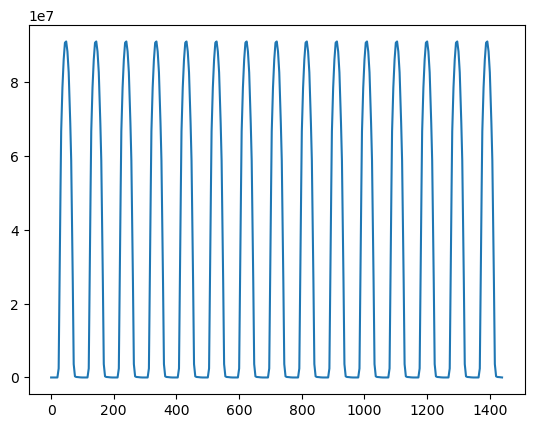

In [14]:
plt.plot(solar_mean_profile_aggregated)

In [15]:
try:
   #  print(f"\n--- Processando dados de Geração Eólica Reais (Média Agregada) do arquivo '{nome_do_arquivo_eolica}' ---")
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
   #  print(f"Perfil Eólico de Média Agregada: {len(wind_mean_profile_aggregated)} pontos.")
   #  print("Primeiros 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil eólico agregado (Watts):", max(wind_mean_profile_aggregated))
   #  print("Valor mínimo no perfil eólico agregado (Watts):", min(wind_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO EÓLICO: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

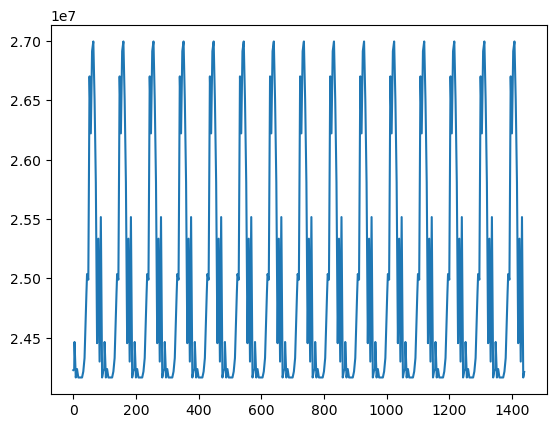

In [16]:
plt.plot(wind_mean_profile_aggregated)

In [17]:
h2_price_to_test = 30.00
ammonia_prices_to_test = [4.00, 5.50]

ammonia_price = ammonia_prices_to_test[0]

# Passamos os perfis de média agregada para solar e eólica para a função
all_scenario_profiles = load_and_process_scenario_data(
    N,
    INTERVALO_HORAS,
    LOAD_MAX_W,               # Carga máxima
    GEN_MAX_W,               # Geração Solar/Eólica máxima
    pld_data=pld_data_for_scenarios,
    solar_mean_profile=solar_mean_profile_aggregated,
    wind_mean_profile=wind_mean_profile_aggregated,
    fixed_h2_price=h2_price_to_test,
    fixed_ammonia_price=ammonia_price
)

#   print("\nIniciando a resolução do Modelo Estocástico...")
all_scenario_names = ["optimal", "good", "bad"]
options = {"solver": "cplex"}

creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
    scenario_name, all_profiles=all_scenario_profiles, **kwargs
)

--- Construindo perfis: Preço H₂ (Venda) = R$ 30.00/kg | Preço Amônia (Venda) = R$ 4.00/kg ---


In [18]:
all_scenario_names

['optimal', 'good', 'bad']

In [19]:
all_scenario_profiles.keys()

dict_keys(['optimal', 'good', 'bad'])

In [20]:
all_scenario_profiles['optimal'].keys()

dict_keys(['wind_gen_w', 'solar_gen_w', 'spot_prices_mwh', 'load_w', 'h2_price_venda', 'ammonia_price_venda'])

In [21]:
creator_with_data('optimal')

In [22]:
options

{'solver': 'cplex'}

In [23]:
ef_builder = ExtensiveForm(options, all_scenario_names, creator_with_data)
solver = pyo.SolverFactory(options["solver"])
results = solver.solve(ef_builder.ef, tee=True)

if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
 #    print(f"\n--- Resultados da Otimização ---")
    ef_model = ef_builder.ef
    
    expected_profit = pyo.value(ef_model.EF_Obj)
    print(f"Valor Objetivo Ótimo (Lucro Esperado Total): R$ {expected_profit:,.2f}")
    
    first_block = getattr(ef_model, all_scenario_names[0])
    initial_socs = {
        'elec': pyo.value(first_block.X['ELEC_INITIAL_SOC']),
        'h2': pyo.value(first_block.X['H2_INITIAL_SOC']),
        'ammonia': pyo.value(first_block.X['AMMONIA_INITIAL_SOC'])
    }
  #   print("\nDecisões do Primeiro Estágio (aqui e agora):")
  #   print(f"  SOC Inicial Ótimo da BESS: {initial_socs['elec'] / 1e6:.2f} MWh")
  #   print(f"  SOC Inicial Ótimo do Tanque de H2: {initial_socs['h2']:.2f} kg")
   #  print(f"  SOC Inicial Ótimo do Tanque de Amônia: {initial_socs['ammonia']:.2f} kg")
    
   #  print("\nParâmetros Econômicos e de Conversão da Simulação:")
   #  print("-" * 50)
   #  print(f"  - Preço de Venda do H₂:       R$ {h2_price_to_test:.2f}/kg")
   #  print(f"  - Preço de Venda da Amônia:   R$ {ammonia_price:.2f}/kg")
    rendimento_h2_nh3 = 1 / TX_H2_TO_AMMONIA_KG_PER_KG
   #  print(f"  - Fator Haber-Bosch (Inverso): {rendimento_h2_nh3:.2f} kg de NH₃ gerados por kg de H₂")
   #  print("-" * 50)

[   11.31] Initializing SPBase

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.2.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2024.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmp7aa1_bjt.cplex.log' open.
CPLEX> Problem '/tmp/tmp4zycoh6m.pyomo.lp' read.
Read time = 0.29 sec. (9.53 ticks)
CPLEX> Problem name         : /tmp/tmp4zycoh6m.pyomo.lp
Objective sense      : Maximize
Variables            :   77769  [Nneg: 30240,  Box: 34569,  Binary: 12960]
Objective nonzeros   :    7200
Linear constraints   :   64797  [Less: 34551,  Equal: 30246]
  Nonzeros           :  203028
  RHS nonzeros       :   25902

Variables            : Min LB: 0.000000         Max UB: 6.000000e+07   
Objective nonzeros   : Min   : 1.526750e-05     Max   : 1.000

In [24]:
ef_model

In [25]:
getattr(ef_model, 'bad')

In [26]:
getattr(ef_model, 'good')

In [27]:
getattr(ef_model, 'optimal')

In [28]:
optimal_model = getattr(ef_model, 'optimal')

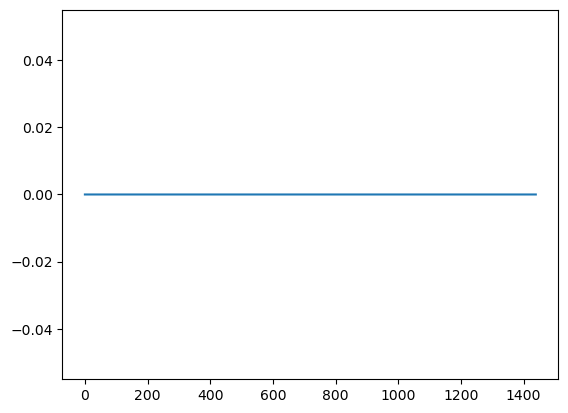

In [29]:
plt.plot(np.array([i.value for i in optimal_model.GRID_BUY_POWER.values()]))

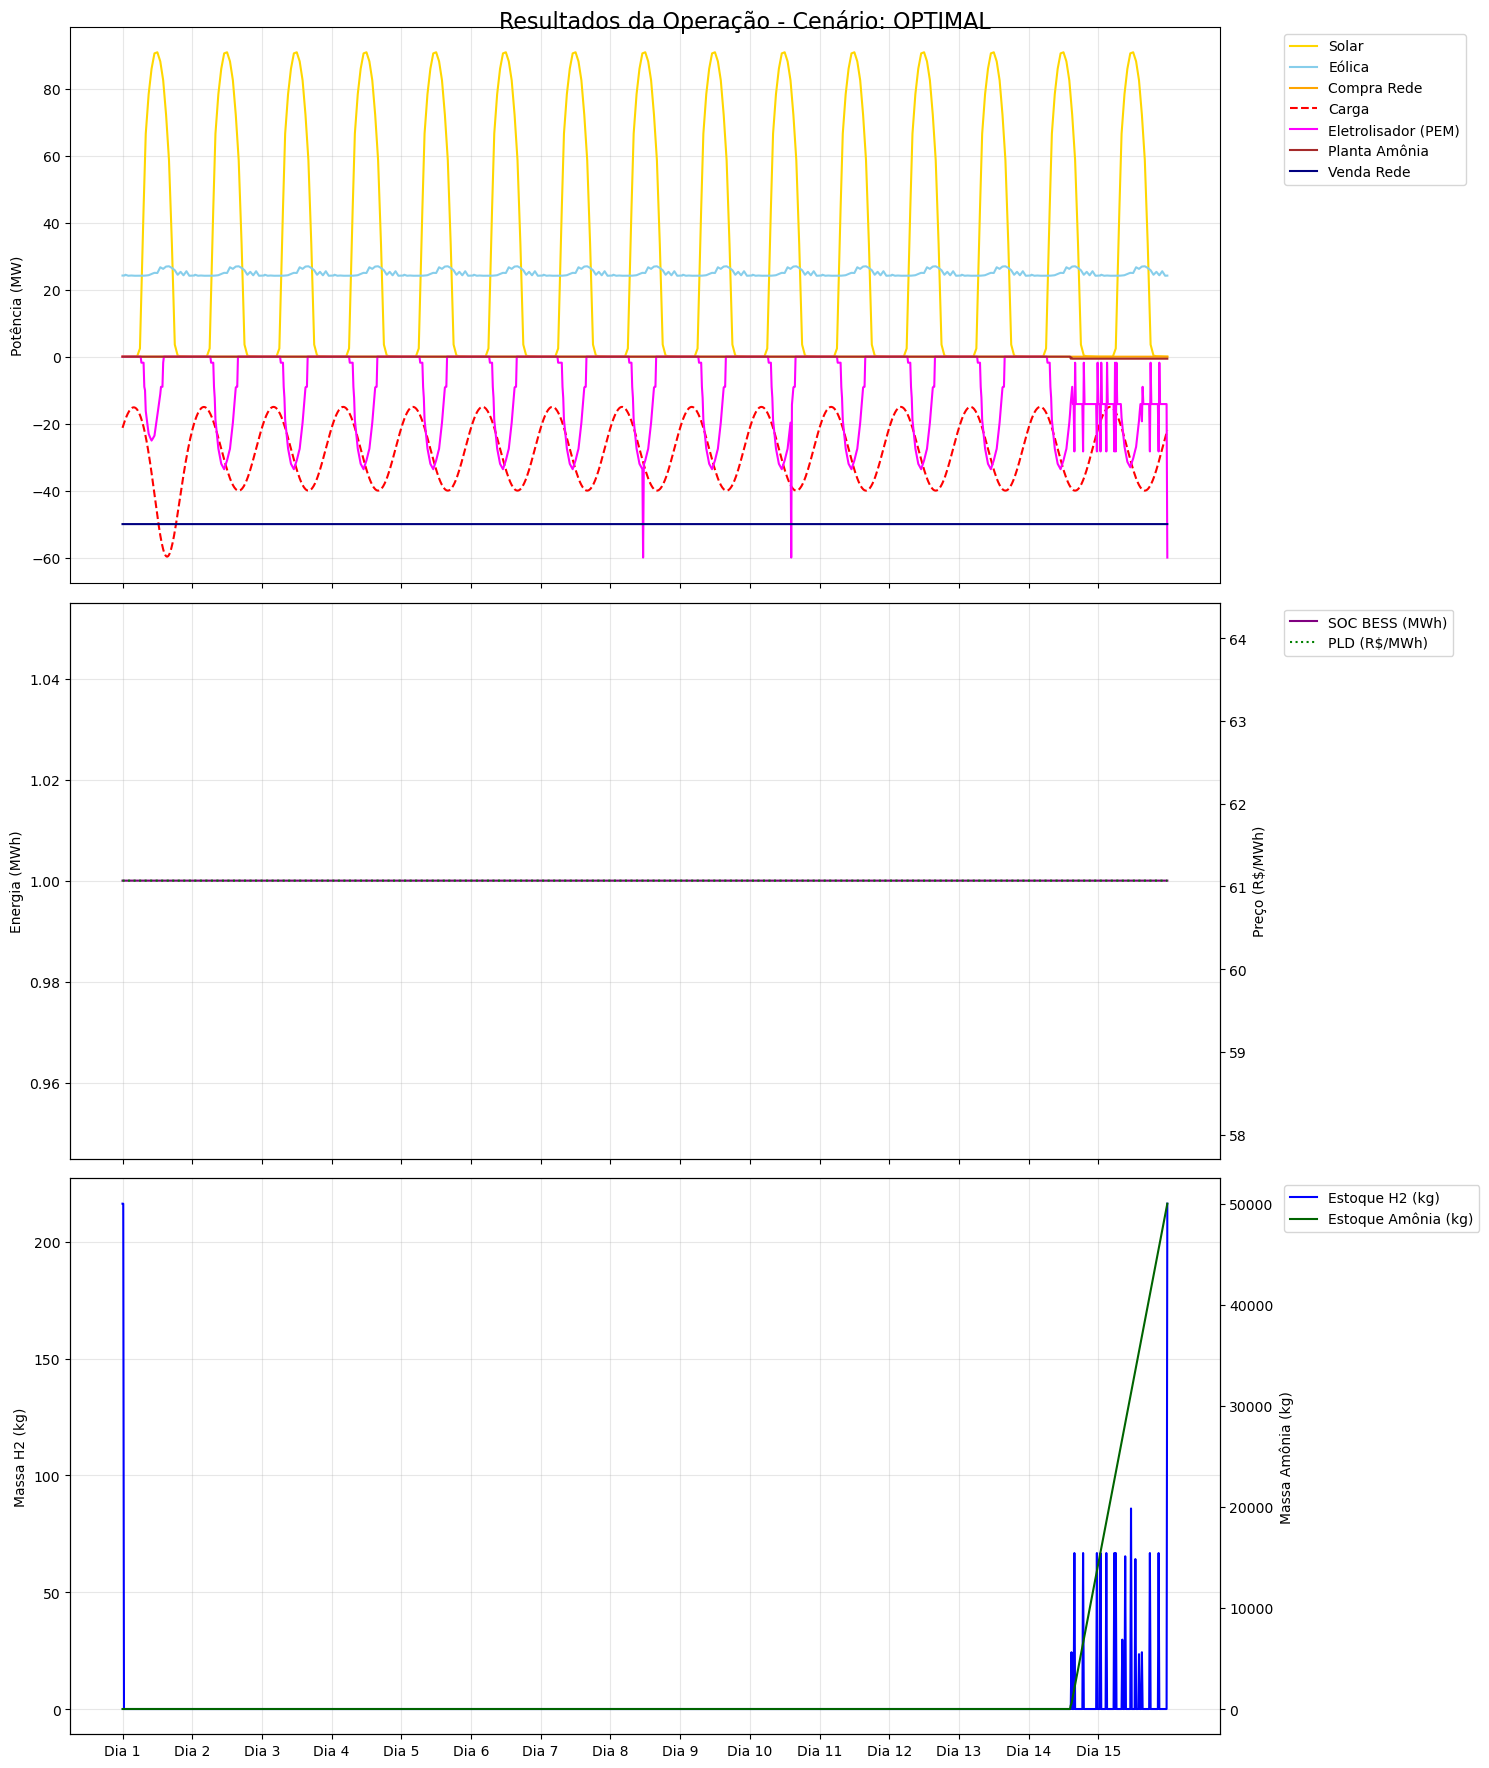

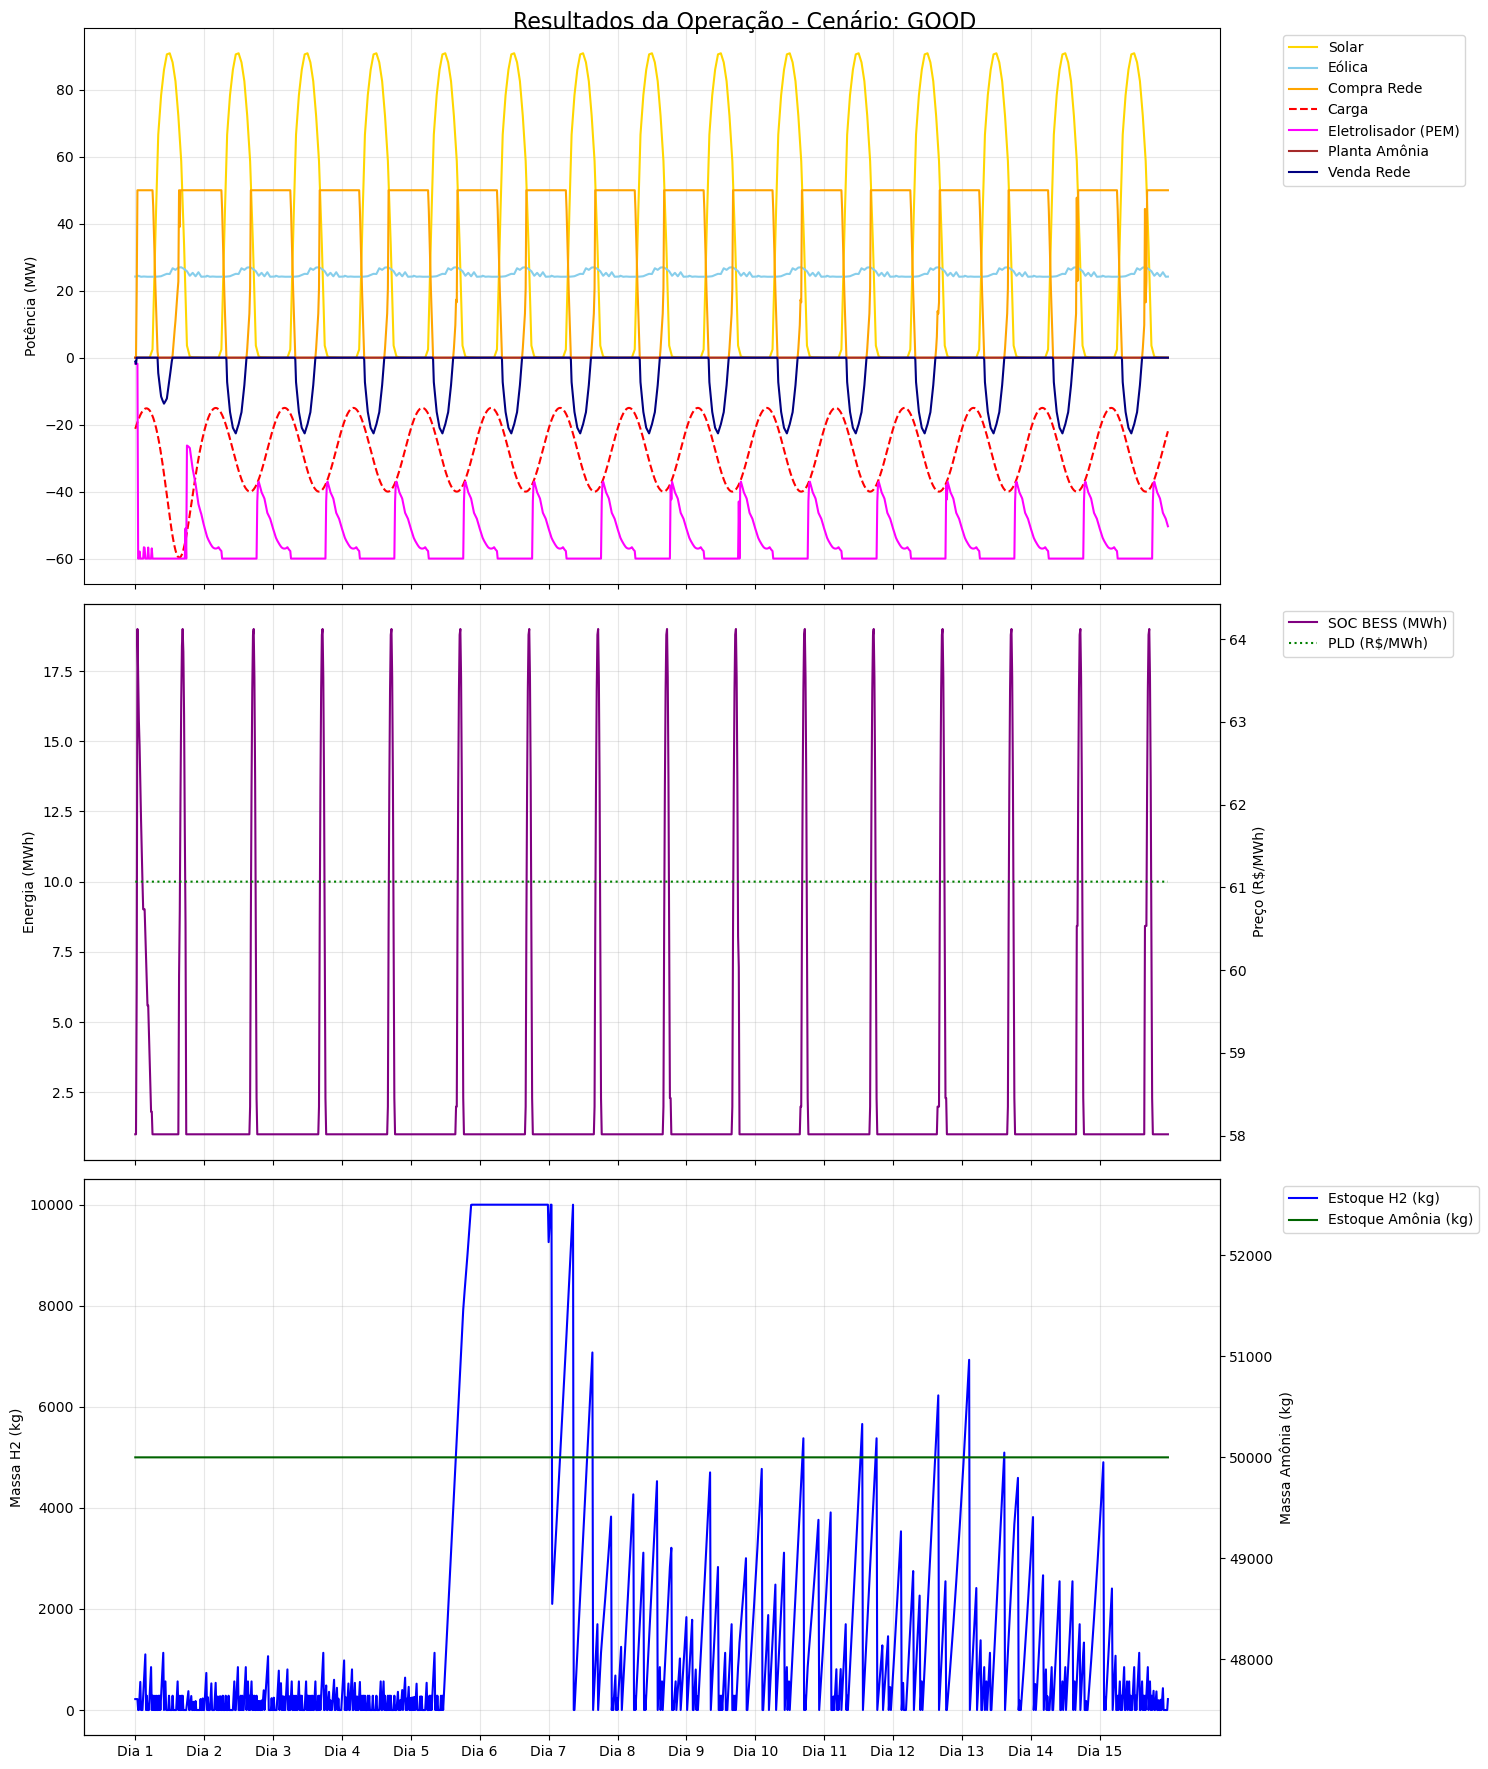

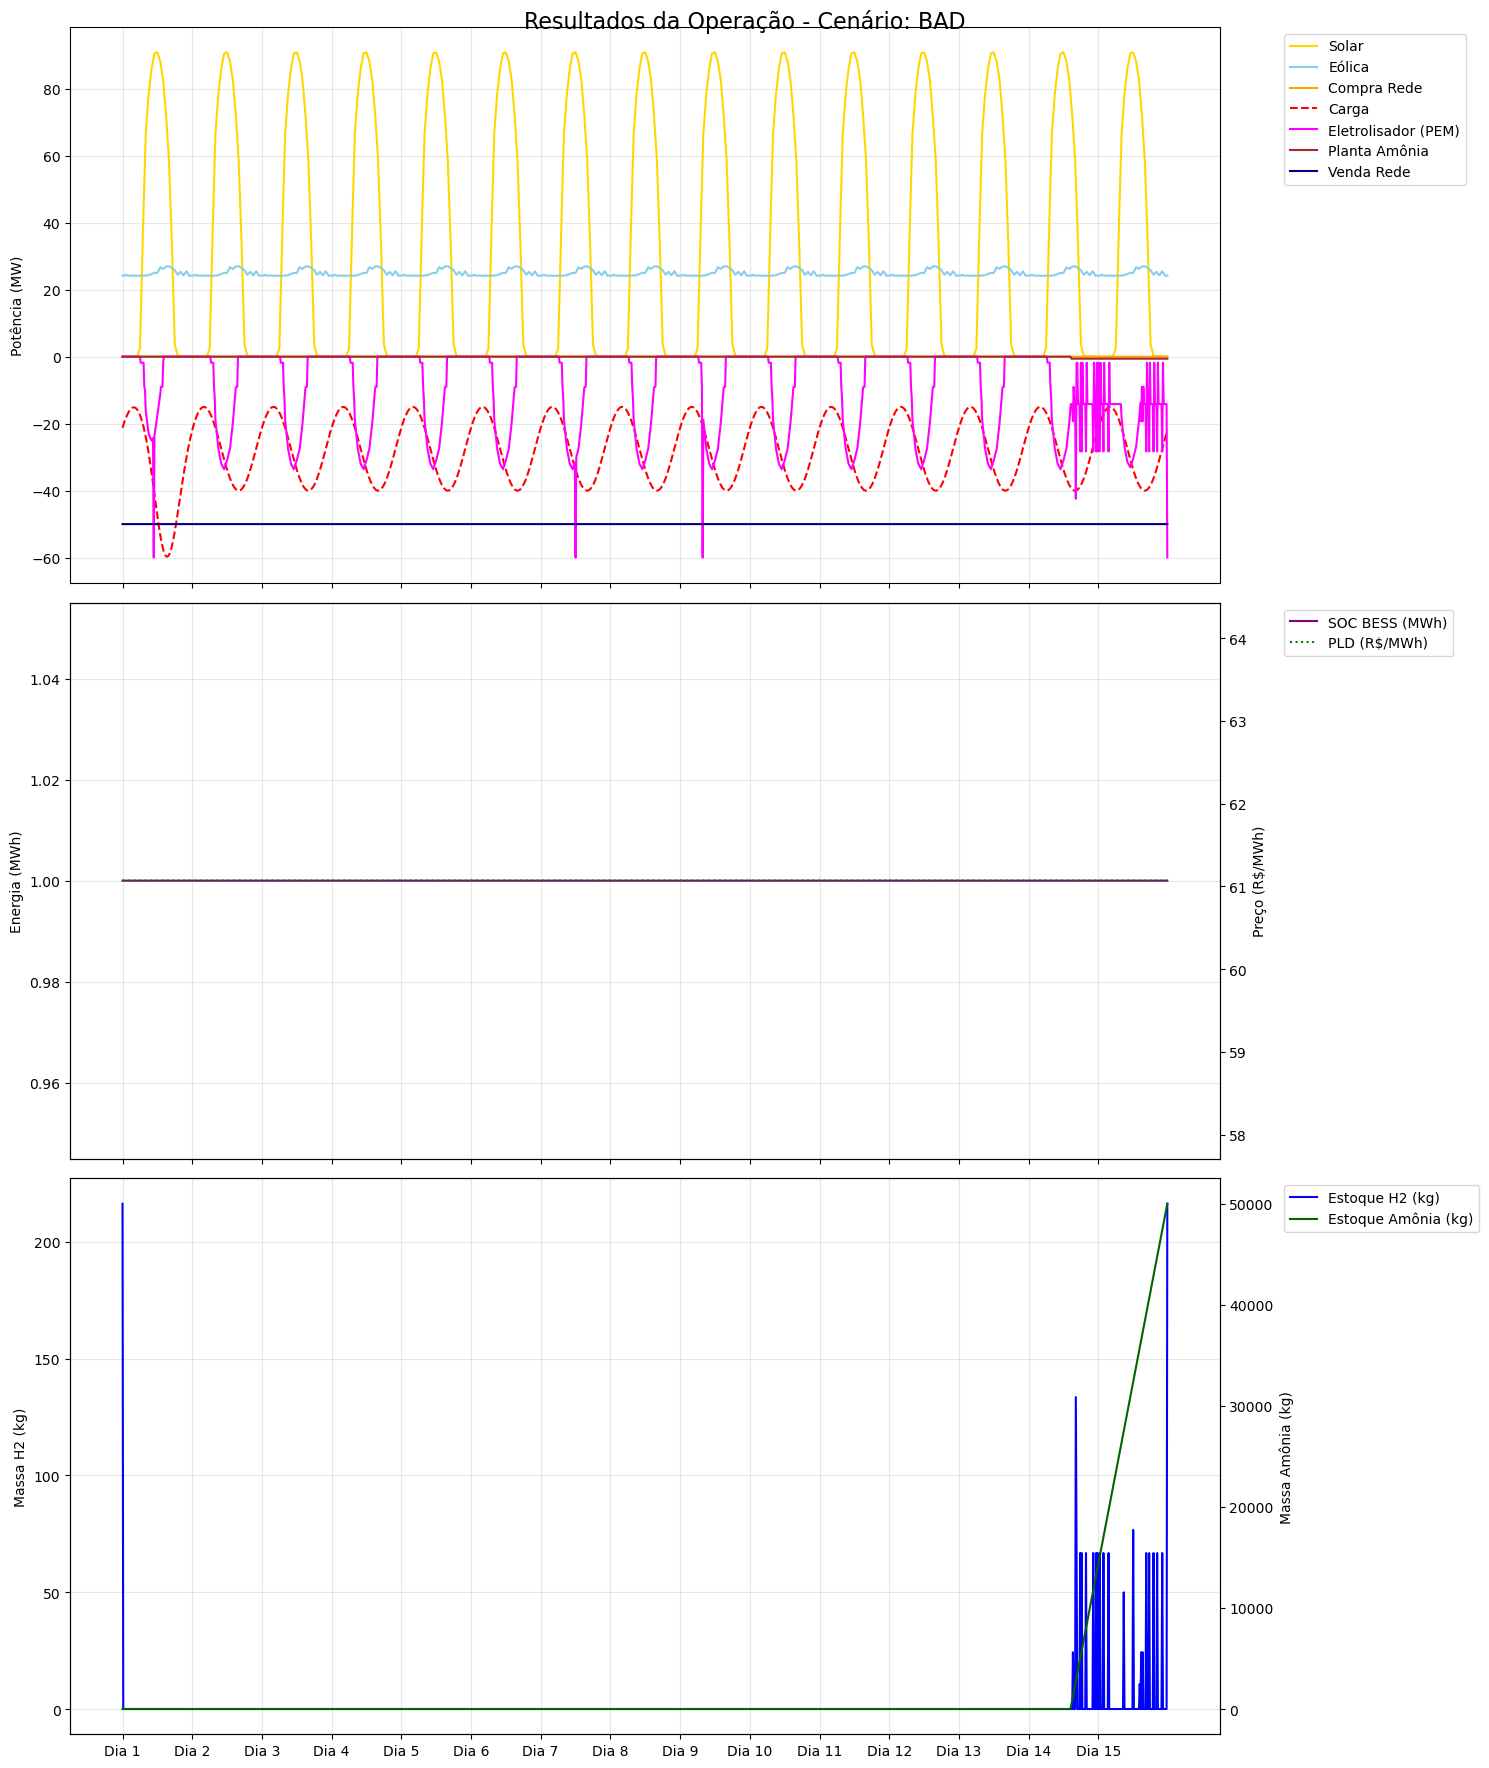

In [30]:
# --- Geração de Gráficos por Cenário ---
if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    ef_model = ef_builder.ef
    
    # O TIME_HORIZON agora é um array de 1440 pontos
    for s_name in all_scenario_names:
        s_block = getattr(ef_model, s_name)
        
        plot_scenario_results(
            TIME_HORIZON,
            s_block, 
            s_name, 
            initial_socs, 
            fixed_h2_price=h2_price_to_test,
            fixed_ammonia_price=ammonia_price,
            AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG=AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG,
            INTERVALO_HORAS=INTERVALO_HORAS,
            N=N,
            h2_max_soc_kg=h2_max_soc_kg,
            h2_min_soc_kg=h2_min_soc_kg,
            ammonia_max_soc_kg=ammonia_max_soc_kg,
            ammonia_min_soc_kg=ammonia_min_soc_kg,
            TX_H2_TO_AMMONIA_KG_PER_KG=TX_H2_TO_AMMONIA_KG_PER_KG
        )
else:
    print(f"\nO solver não encontrou uma solução ótima. Condição: {results.solver.termination_condition}")